# Запуск обучения всех моделей и сравнение логов

1. Запускает по очереди обучение REINFORCE, REINFORCE+baseline и TRPO (те же параметры, что в `scripts/train_*.sh`).
2. Строит на одном наборе графиков все метрики из папки `logs/` по каждому из трёх логов.

**Внимание:** при повторном запуске ячеек обучения файлы в `logs/` будут перезаписаны. Чтобы сохранить старые результаты, скопируйте их до повторного обучения.

In [1]:
import json
import subprocess
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: /Users/vasilij/Documents/RL_proj2


In [ ]:
# 1. Обучение REINFORCE (перезаписывает logs/training_history_reinforce.json)
# subprocess.run(
#     ["python", "run/train.py",
#      "--num_disks", "4", "--num_sticks", "3",
#      "--agent_method", "reinforce",
#      "--reward_step", "-200.0", "--reward_goal", "4000.0",
#      "--reward_invalid_move", "-50.0", "--reward_correct_placement", "100",
#      "--use_correct_placement",
#      "--num_episodes", "10000", "--max_steps", "200",
#      "--log_interval", "50", "--checkpoint_interval", "1000",
#      "--random_init", "--no-entropy_adaptive",
#      "--entropy_coef", "250", "--max_grad_norm", "200.0",
#      "--save_model", "model_reinforce.pth",
#      "--history_path", "logs/training_history_reinforce.json"],
#     cwd=PROJECT_ROOT,
#     check=True,
# )
# print("REINFORCE done.")

2026-03-04 01:10:32 [INFO] === Starting Training Session ===
2026-03-04 01:10:32 [INFO] Method: reinforce | Disks: 4
2026-03-04 01:10:36 [INFO] episode=50 | reward=-35543.00 | steps=181 | success=False | success_rate=20.0% | loss=-19795.1367 | entropy=1.5771 | entropy_coef=250.0000
2026-03-04 01:10:39 [INFO] episode=100 | reward=-37271.00 | steps=182 | success=False | success_rate=12.0% | loss=-17836.7227 | entropy=1.5405 | entropy_coef=250.0000
2026-03-04 01:10:43 [INFO] episode=150 | reward=-37708.00 | steps=185 | success=False | success_rate=16.0% | loss=3366.7563 | entropy=1.4616 | entropy_coef=250.0000
2026-03-04 01:10:46 [INFO] episode=200 | reward=-35507.00 | steps=176 | success=False | success_rate=20.0% | loss=-11410.5654 | entropy=1.5452 | entropy_coef=250.0000
2026-03-04 01:10:49 [INFO] episode=250 | reward=-33476.00 | steps=166 | success=False | success_rate=30.0% | loss=-16580.3320 | entropy=1.3471 | entropy_coef=250.0000
2026-03-04 01:10:52 [INFO] episode=300 | reward=-34

Successfully saved training history to logs/training_history_reinforce.json
REINFORCE done.


In [ ]:
# 2. Обучение REINFORCE+baseline (перезаписывает logs/training_history_reinforce_baseline.json)
# subprocess.run(
#     [sys.executable, "run/train.py",
#      "--num_disks", "4", "--num_sticks", "3",
#      "--agent_method", "reinforce_baseline",
#      "--reward_step", "-200.0", "--reward_goal", "4000.0",
#      "--reward_invalid_move", "-50.0", "--reward_correct_placement", "100",
#      "--use_correct_placement",
#      "--num_episodes", "10000", "--max_steps", "200",
#      "--log_interval", "50", "--checkpoint_interval", "1000",
#      "--random_init", "--no-entropy_adaptive",
#      "--entropy_coef", "250", "--max_grad_norm", "200.0",
#      "--save_model", "model_reinforc1e_baseline.pth",
#      "--history_path", "logs/training_history_reinforce_baseline.json"],
#     cwd=PROJECT_ROOT,
#     check=True,
# )
# print("REINFORCE+baseline done.")

2026-03-04 01:13:57 [INFO] === Starting Training Session ===
2026-03-04 01:13:57 [INFO] Method: reinforce_baseline | Disks: 4
2026-03-04 01:14:01 [INFO] episode=50 | reward=-29323.00 | steps=153 | success=False | success_rate=34.0% | loss=-1639.5066 | entropy=1.5902 | entropy_coef=0.0100
2026-03-04 01:14:04 [INFO] episode=100 | reward=-32732.00 | steps=168 | success=False | success_rate=24.0% | loss=7724.6323 | entropy=1.1801 | entropy_coef=0.0100
2026-03-04 01:14:07 [INFO] episode=150 | reward=-31498.00 | steps=157 | success=False | success_rate=32.0% | loss=5.3317 | entropy=1.0288 | entropy_coef=0.0100
2026-03-04 01:14:09 [INFO] episode=200 | reward=-29080.00 | steps=155 | success=False | success_rate=36.0% | loss=12561.1611 | entropy=1.4218 | entropy_coef=0.0100
2026-03-04 01:14:12 [INFO] episode=250 | reward=-30954.00 | steps=161 | success=False | success_rate=34.0% | loss=-993.8352 | entropy=1.4404 | entropy_coef=0.0100
2026-03-04 01:14:15 [INFO] episode=300 | reward=-29217.00 | s

Successfully saved training history to logs/training_history_reinforce_baseline.json
REINFORCE+baseline done.


In [2]:
# 3. Обучение TRPO (перезаписывает logs/training_history_trpo.json)
subprocess.run(
    [sys.executable, "run/train.py",
     "--num_disks", "4", "--num_sticks", "3",
     "--agent_method", "trpo",
     "--reward_step", "-200.0", "--reward_goal", "4000.0",
     "--reward_invalid_move", "-50.0", "--reward_correct_placement", "100",
     "--use_correct_placement",
     "--num_episodes", "10000", "--max_steps", "200",
     "--log_interval", "50", "--checkpoint_interval", "1000",
     "--random_init", "--no-entropy_adaptive",
     "--entropy_coef", "250",
     "--save_model", "model_trpo.pth",
     "--history_path", "logs/training_history_trpo.json"],
    cwd=PROJECT_ROOT,
    check=True,
)
print("TRPO done.")

2026-03-04 01:43:13 [INFO] === Starting Training Session ===
2026-03-04 01:43:13 [INFO] Method: trpo | Disks: 4
2026-03-04 01:43:16 [INFO] episode=50 | reward=-45185.00 | steps=200 | success=False | success_rate=0.0% | loss=192.7297 | entropy=0.1598 | entropy_coef=250.0000
2026-03-04 01:43:18 [INFO] episode=100 | reward=-41013.00 | steps=200 | success=False | success_rate=0.0% | loss=21.3751 | entropy=0.0008 | entropy_coef=250.0000
2026-03-04 01:43:20 [INFO] episode=150 | reward=-37179.00 | steps=200 | success=False | success_rate=0.0% | loss=200.1652 | entropy=0.0000 | entropy_coef=250.0000
2026-03-04 01:43:22 [INFO] episode=200 | reward=-43373.00 | steps=200 | success=False | success_rate=0.0% | loss=180.0300 | entropy=0.0000 | entropy_coef=250.0000
2026-03-04 01:43:24 [INFO] episode=250 | reward=-39175.00 | steps=200 | success=False | success_rate=0.0% | loss=22.2617 | entropy=0.0000 | entropy_coef=250.0000
2026-03-04 01:43:26 [INFO] episode=300 | reward=-40093.00 | steps=196 | succ

KeyboardInterrupt: 

## Графики как в plot.py: Reward, Success Rate, Steps (все модели на одной figure)

Три подграфика в столбец: (1) Total Reward per Episode, (2) Success Rate (Rolling Window 100), (3) Steps per Episode. На каждом — кривые для REINFORCE, REINFORCE+baseline и TRPO.

In [5]:
LOG_FILES = {
    "REINFORCE": PROJECT_ROOT / "logs" / "training_history_reinforce.json",
    "REINFORCE+baseline": PROJECT_ROOT / "logs" / "training_history_reinforce_baseline.json",
    "TRPO": PROJECT_ROOT / "logs" / "training_history_trpo.json",
}

def load_history(path):
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

histories = {name: load_history(p) for name, p in LOG_FILES.items()}
missing = [n for n, h in histories.items() if h is None]
if missing:
    raise FileNotFoundError(
        "Сначала запустите ячейки обучения. Не найдены: " + ", ".join(missing)
    )

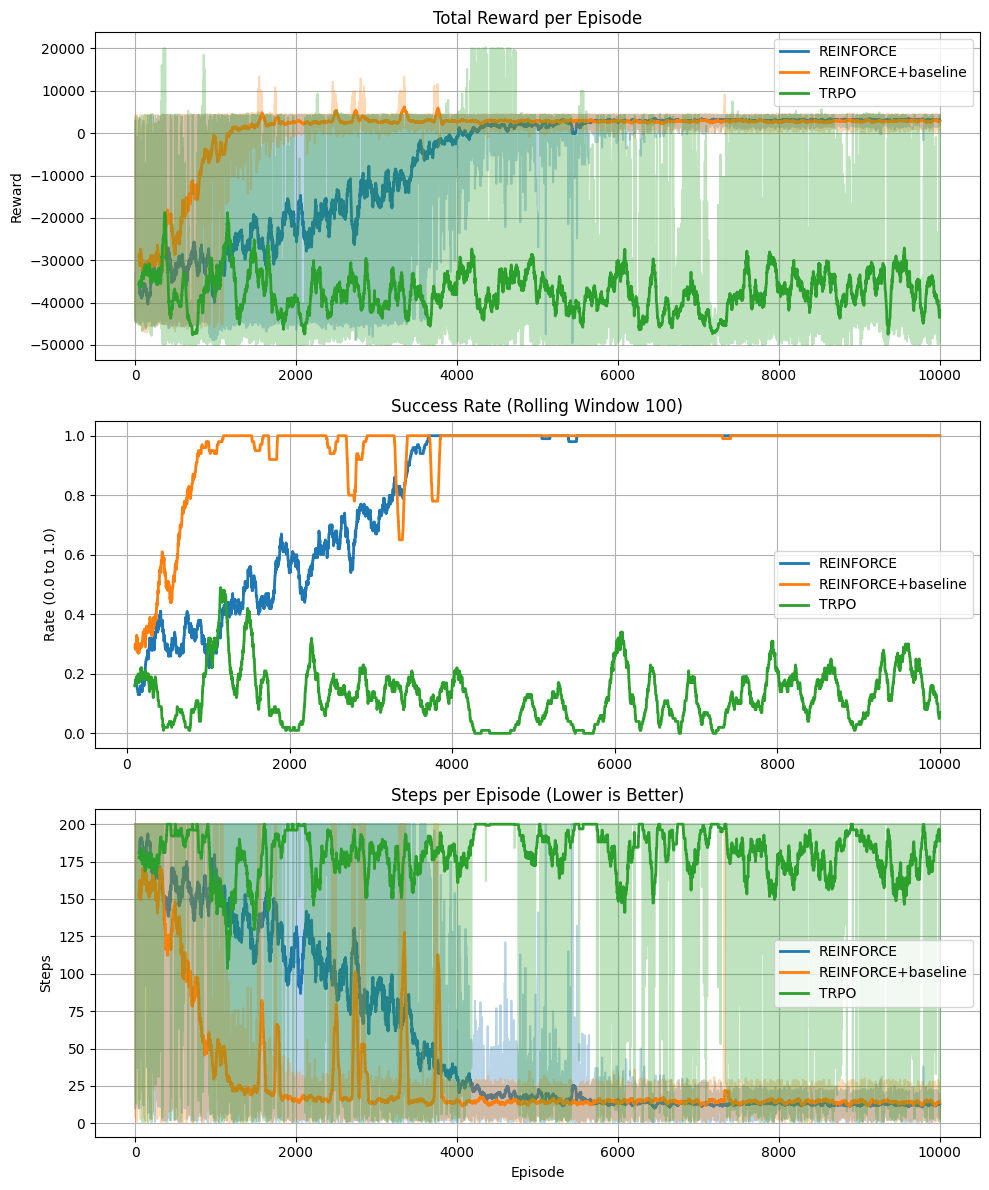

График сохранён: /Users/vasilij/Documents/RL_proj2/experiments/training_curves.png


In [6]:
def moving_average(data, window=50):
    """Сглаживание графика для лучшей читаемости (как в plot.py)."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="valid")

colors = {"REINFORCE": "C0", "REINFORCE+baseline": "C1", "TRPO": "C2"}

# Как в plot.py: 3 графика в столбец
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Total Reward per Episode
for name, history in histories.items():
    if not history:
        continue
    rewards = np.array([h["reward"] for h in history])
    ax1.plot(rewards, alpha=0.3, color=colors[name])
    ma = moving_average(rewards, 50)
    if len(ma) > 0:
        ax1.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax1.set_title("Total Reward per Episode")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(True)

# 2. Success Rate (Rolling Window 100)
for name, history in histories.items():
    if not history:
        continue
    success = np.array([h["success"] for h in history], dtype=float)
    success_smooth = moving_average(success, 100)
    if len(success_smooth) > 0:
        ax2.plot(np.arange(99, 99 + len(success_smooth)), success_smooth, color=colors[name], linewidth=2, label=name)
ax2.set_title("Success Rate (Rolling Window 100)")
ax2.set_ylabel("Rate (0.0 to 1.0)")
ax2.set_ylim(-0.05, 1.05)
ax2.legend()
ax2.grid(True)

# 3. Steps per Episode (Lower is Better)
for name, history in histories.items():
    if not history:
        continue
    steps = np.array([h["steps"] for h in history])
    ax3.plot(steps, alpha=0.3, color=colors[name])
    ma = moving_average(steps, 50)
    if len(ma) > 0:
        ax3.plot(np.arange(49, 49 + len(ma)), ma, color=colors[name], linewidth=2, label=name)
ax3.set_title("Steps per Episode (Lower is Better)")
ax3.set_ylabel("Steps")
ax3.set_xlabel("Episode")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
out_path = PROJECT_ROOT / "experiments" / "training_curves.png"
plt.savefig(out_path, dpi=120)
plt.show()
print("График сохранён:", out_path)